<a href="https://colab.research.google.com/github/besturkmen/AcademiQ_Data_Science/blob/main/AcademiQ_Data_Science_02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# MP = Veri kalitesi * Özellik Mühendisliği * Model Seçimi

# Garbage in garbage out kuralı



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #görselleştirme ekleyeceğimiz için
import seaborn as sns
from scipy import stats



#Eksik veri

NaN doldurmak değil

MCAR (Missing Completely At Random) = Bu durumda eksik veri mekanizması tamamen rastgeledir; yani bir değerin eksik olması veri setindeki hiçbir değişkenle ilişkili değildir.

MAR (Missing at Random) = MAR durumundaki eksiklik mekanizması , gözlemlenebilen diğer değişkenlere bağlıdır. Ancak eksik olan değerin kendisine doğrudan bağlı değildir.

MNAR (Missing Not at Random) = Eksiklik mekanizması direkt eksik değerin kendisi ile ilişkilidir.

In [5]:
df = pd.read_csv("ecommerce_synthetic.csv")
df.head()

,musteri_yasi,sehir,cinsiyet,aylik_gelir,toplam_harcama,siparis_sayisi,ortalama_sepet,musteri_id,churn
0,23.0,Sehir_23,Erkek,8049.274797,14535.327035,7.0,258.185054,USR000000,0
1,62.0,Sehir_4,Kadin,89714.014583,8163.295595,16.0,254.973152,USR000001,1
2,55.0,Sehir_75,Kadin,93543.316734,NaN,14.0,131.260394,USR000002,0
3,43.0,Sehir_81,Erkek,24847.354037,4153.712409,9.0,264.570862,USR000003,1
4,NaN,Sehir_92,Erkek,55106.378151,2244.512978,32.0,447.399667,USR000004,0


In [9]:
sayisal = df.select_dtypes("number").drop(columns="churn")

karşilaştirma = pd.DataFrame({
    "mean": sayisal.mean(),
    "median": sayisal.median(),
    "oran": sayisal.mean() / sayisal.median() ,
    "skew": sayisal.skew() ,
})
karşilaştirma

,mean,median,oran,skew
musteri_yasi,45.972421,46.000000,0.999400,0.023048
aylik_gelir,49911.457613,35667.765765,1.399344,4.078571
toplam_harcama,16805.494201,8339.851885,2.015083,4.870924
siparis_sayisi,20.660312,21.000000,0.983824,-0.005164
ortalama_sepet,385.389417,358.383566,1.075355,19.273607


Oran 1 değerine ne kadar yakınsa o kadar dengeli bir veriseti ,dengeli bir dağılım vardır diyebiliriz.

Oran 1 den büyük ise sağa çarpıktır. Yüksek değerli outlier lar mevcuttur.

Oran 1 den daha düşükse sola çarpıklık vardır. Çok yüksek gelirli bir müşterinin çok az harcaması gibi yorumlayabiliriz.

0 normal dağılımdır.


In [10]:
eksik = df.isnull().mean().mul(100).round(2).rename("eksik_pct")
eksik = eksik[ eksik > 0].sort_values(ascending=False ) #Hiç eksik olmayan sütunlardan kurtulup büyükten küçüğe(sort values(ascending=False)) sıralama yapar.
print(eksik.to_string())

siparis_sayisi    19.22
toplam_harcama     8.74
musteri_yasi       5.00


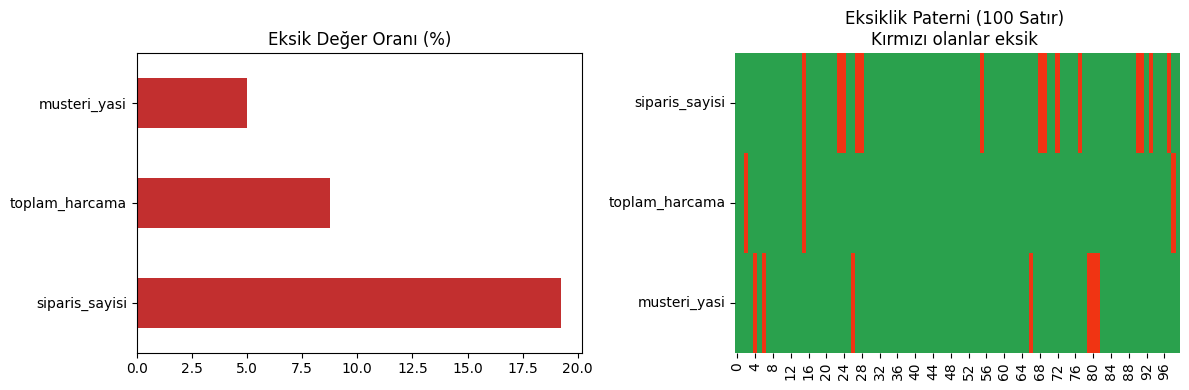

In [15]:
fig, axes = plt.subplots(1, 2 , figsize=(12,4))
eksik.plot(kind="barh", ax=axes[0], color= "#c22f2f")
axes[0].set_title("Eksik Değer Oranı (%)")

sns.heatmap(
    df[eksik.index].head(100).isnull().T,
    ax=axes[1], cmap=["#2aa14d","#f03413"], cbar=False
)
axes[1].set_title("Eksiklik Paterni (100 Satır) \nKırmızı olanlar eksik ")
plt.tight_layout() #grafiklerin üst üste binmesini engeller.
plt.show() #grafiği ekrana basar.

In [24]:
def siniflandir(df, col):
  eksik_flag=df[col].isnull().astype(int)
  sayisal_sutunlar=df.select_dtypes("number").columns.drop(col, errors="ignore")

  for x in sayisal_sutunlar:
    mask=df[x].notna()
    if mask.sum()<30:
      continue
    _,p =stats.pointbiserialr(eksik_flag[mask], df.loc[mask,x])
    if p < 0.05:
      return f"MAR ('{x}' ile ilişkili, p={p:.4f})"
  if col in df.select_dtypes("number").columns:
    tam=df[col].dropna()
    if(df[df[col]>=tam.quantile(0.8)][col].isnull().mean())> 0.15:
      return "MNAR (uç değerler daha fazla eksik)"

  return "MCAR (rastgele eksik)"

for col in ["musteri_yasi","toplam_harcama","siparis_sayisi"]:
  pct =df[col].isnull().mean()*100
  print(f"{col:20s} %{pct:.1f} -> {siniflandir(df,col)}")

musteri_yasi         %5.0 -> MCAR (rastgele eksik)
toplam_harcama       %8.7 -> MAR ('aylik_gelir' ile ilişkili, p=0.0000)
siparis_sayisi       %19.2 -> MCAR (rastgele eksik)
